# Ex9: CNN AlexNet CIFAR-10

In [1]:
import torch
import torchvision.transforms as transforms
import torchvision.datasets as dataset
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

In [2]:
train_dataset = dataset.CIFAR10('../DATA',train=True,transform=transforms.ToTensor(),download=True)
test_dataset = dataset.CIFAR10('../DATA',train=False,transform=transforms.ToTensor(),download=True)

Text(0.5, 1.0, 'frog')

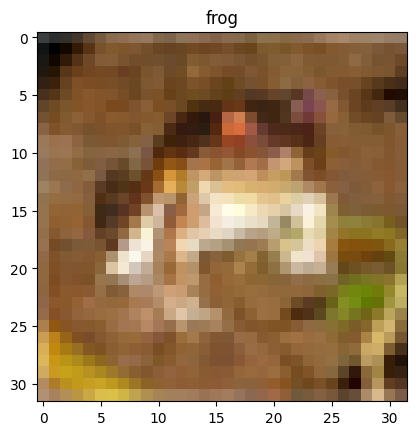

In [3]:
plt.imshow(train_dataset.data[0])
plt.title(train_dataset.classes[train_dataset.targets[0]])

In [4]:
print(f'X Train shape {train_dataset.data.shape} y train shape {np.array(train_dataset.targets).shape}')
print(f'X Train shape {test_dataset.data.shape} y train shape {np.array(test_dataset.targets).shape}')


X Train shape (50000, 32, 32, 3) y train shape (50000,)
X Train shape (10000, 32, 32, 3) y train shape (10000,)


In [5]:
train_loader = torch.utils.data.DataLoader(train_dataset,batch_size=128,shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset,batch_size=128,shuffle=False)

## AlexNet class (sort of)

In [6]:
class AlexNet(nn.Module):
    def __init__(self,in_channel=3,classses = 10):
        super().__init__()
        self.c1 = nn.Conv2d(in_channels=in_channel,out_channels=96,kernel_size=3,stride=1,padding=1) # (32x32x3) -> (32-3-2+1)=32x32x96
        self.p1 = nn.MaxPool2d(kernel_size=2,stride=2) #(32-2)/2 +1 = 16x16x96
        self.c2 = nn.Conv2d(in_channels=96,out_channels=192,kernel_size=3,stride=1,padding=1) # (16-3+2+1) = 16x16x192
        self.p2 = nn.MaxPool2d(kernel_size=2,stride=2) # 8x8x192
        self.c3 = nn.Conv2d(in_channels=192,out_channels=384,kernel_size=3,padding=1) # 8x8x384
        self.p3 = nn.MaxPool2d(kernel_size=2,stride=2)
        self.c4 = nn.Conv2d(in_channels=384,out_channels=256,kernel_size=3,padding=1) # 4x4x256
        self.c5 = nn.Conv2d(in_channels=256,out_channels=256,kernel_size=3,padding=1) # 4x4x256
        self.p4 = nn.MaxPool2d(kernel_size=2,stride=2)# (4-2)/2+1= 2x2x256
        self.flat = nn.Flatten()
        self.fc1 = nn.Linear(2*2*256,512)
        self.drp1 = nn.Dropout()
        self.fc2 = nn.Linear(512,256)
        self.drp2 = nn.Dropout()
        self.fc3 = nn.Linear(256,classses)

    def forward(self,x): 
        x = self.c1(x)
        x = F.relu(x)
        x = self.p1(x)

        x = self.c2(x)
        x = F.relu(x)
        x = self.p2(x)
        x = self.c3(x)
        x = F.relu(x)
        x = self.p3(x)
        x = self.c4(x)
        x= F.relu(x)
        x = self.c5(x)
        x= F.relu(x)
        x = self.p4(x)
        x = self.flat(x)
        x = self.fc1(x)
        x= F.relu(x)
        # x = self.drp1(x)
        x = self.fc2(x)
        x= F.relu(x)
        # x = self.drp2(x)
        return self.fc3(x)




torch.Size([128, 96, 32, 32])
torch.Size([128, 96, 16, 16])
torch.Size([128, 192, 16, 16])
torch.Size([128, 192, 8, 8])
torch.Size([128, 384, 8, 8])
torch.Size([128, 256, 8, 8])
torch.Size([128, 256, 8, 8])
torch.Size([128, 256, 4, 4])
torch.Size([128, 4096])
torch.Size([128, 512])
torch.Size([128, 256])

In [7]:
model = AlexNet(3,10)
print(model)

AlexNet(
  (c1): Conv2d(3, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (p1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (c2): Conv2d(96, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (p2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (c3): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (p3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (c4): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (c5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (p4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flat): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=1024, out_features=512, bias=True)
  (drp1): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (drp2): Dropout(p=0.5, inplace=False)
  (fc3): Linear(in_features=256, ou

## training

In [8]:
epochs = 100
train_losses =[]
test_losses = []
train_acc =[]
test_acc = []


In [9]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model.to(device=device)
criterion = nn.CrossEntropyLoss()
criterion.to(device=device)
optimizer = torch.optim.Adam(model.parameters(),lr=0.00001)

In [10]:
def single_epoch(loader: torch.utils.data.DataLoader, epoch: int ,is_training = False):
    tmp_loss = []
    c_total = 0
    c_current=0

    for X,y in loader:
        if is_training:
            optimizer.zero_grad()
        
        X = X.to(device)
        y = y.to(device)

        y_hat = model(X)

        loss = criterion(y_hat,y)

        if is_training:
            loss.backward()
            optimizer.step()

        tmp_loss.append(loss.item())
        c_total += X.shape[0]
        
        _,argmax = torch.max(y_hat,1)

        c_current += (argmax == y).sum().item()
    
    acc = c_current / c_total
    return acc, np.mean(tmp_loss)

In [11]:
from datetime import datetime as dt

starttime = dt.now()
for epoch in range(1,epochs+1):
   
   acc,loss = single_epoch(train_loader,epoch,True)
   train_losses.append(loss)
   train_acc.append(acc)
   acc,loss = single_epoch(test_loader,epoch,False)
   test_acc.append(acc)
   test_losses.append(loss.item())
   print(f'{dt.now()-starttime}:: {epoch}/{epochs}train loss {train_losses[-1]} train acc {train_acc[-1]} test loss {test_losses[-1]} test acc {test_acc[-1]}')

0:00:06.151698:: 1/100train loss 2.1605231313754225 train acc 0.18072 test loss 2.008867331697971 test acc 0.2592
0:00:12.024212:: 2/100train loss 1.9721880279233694 train acc 0.26142 test loss 1.9210760201079935 test acc 0.2663
0:00:17.874103:: 3/100train loss 1.8789138275644053 train acc 0.29044 test loss 1.8203632907022405 test acc 0.3244
0:00:23.732630:: 4/100train loss 1.7816058436927893 train acc 0.33106 test loss 1.7414104908327512 test acc 0.3479
0:00:29.563212:: 5/100train loss 1.724649618348807 train acc 0.34884 test loss 1.7126064587242995 test acc 0.3526
0:00:35.405239:: 6/100train loss 1.689474204007317 train acc 0.36112 test loss 1.6624253746829456 test acc 0.3757
0:00:41.253496:: 7/100train loss 1.6630150241315211 train acc 0.37382 test loss 1.6394432360612894 test acc 0.3843
0:00:47.149215:: 8/100train loss 1.6398745314849308 train acc 0.38512 test loss 1.6167410370669788 test acc 0.3937
0:00:53.024293:: 9/100train loss 1.616965651512146 train acc 0.3955 test loss 1.597

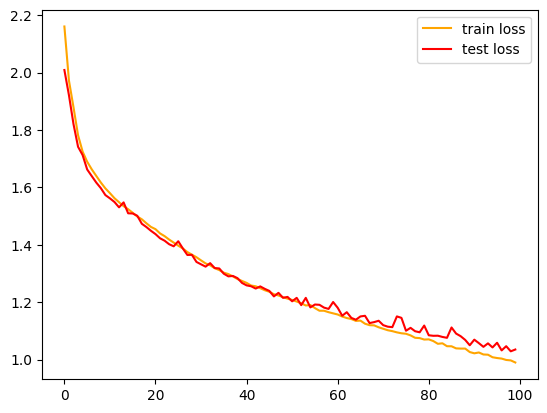

In [12]:
its = [x for x in range(epochs)]
plt.plot(train_losses,label='train loss',color='orange')
plt.plot(test_losses,label='test loss',color='red')
plt.legend()

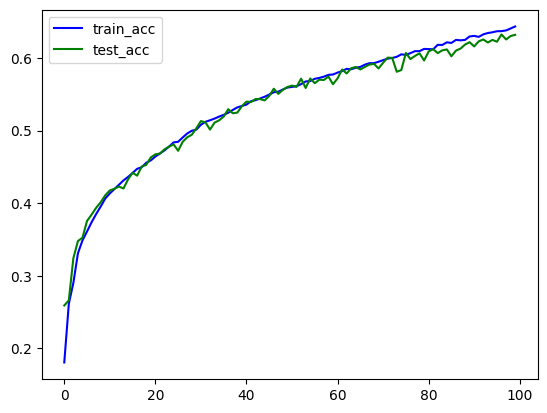

In [13]:
plt.plot(train_acc,label='train_acc',color='blue')
plt.plot(test_acc,label='test_acc',color='green')
plt.legend()

In [20]:
from sklearn.metrics import ConfusionMatrixDisplay

In [19]:

Y_hats = []
Y = []

for X,y in test_loader:
    X,y = X.to(device),y.to(device)
    y_hat = model(X)
    _,y_hat = torch.max(y_hat,1)

    with torch.no_grad():
        Y = np.concatenate((Y,y.cpu().numpy()))
        Y_hats = np.concatenate((Y_hats,y_hat.cpu().numpy()))

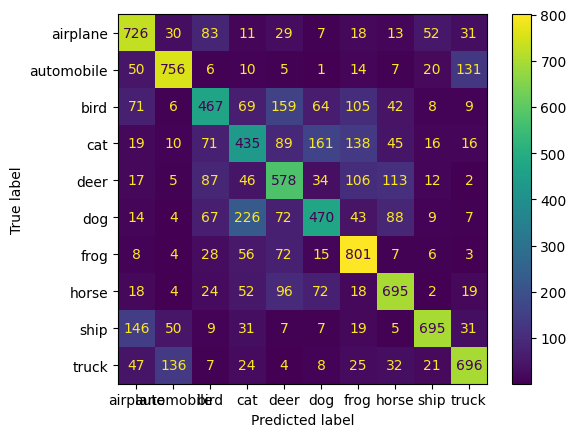

In [21]:
ConfusionMatrixDisplay.from_predictions(Y,Y_hats,display_labels=test_dataset.classes)

In [22]:
idxs = np.where(Y != Y_hats)[0]

3 4


Text(0.5, 1.0, 'cat as deer')

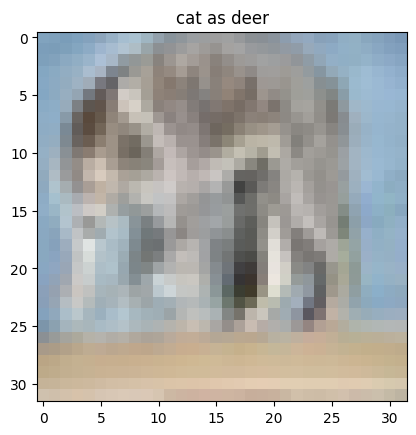

In [45]:
i = np.random.choice(idxs)
plt.imshow(test_dataset.data[i])
t,f = int(Y[i]),int(Y_hats[i])
print(t,f)
plt.title(f'{test_dataset.classes[t]} as {test_dataset.classes[f]}')